# Proyecto Final ML: Predicción de Riesgo de Quiebra

Este notebook corresponde al proyecto final de la especialización de *Machine Learning*. El objetivo es desarrollar un modelo de *machine learning* que prediga el riesgo de quiebra de una empresa a partir de variables financieras y temporales. La estructura del documento recorre desde la presentación del caso de uso y motivación hasta la interpretación final de los modelos, ofreciendo un panorama completo del proceso analítico y decisional.

**Entorno** · Python 3.10

_Última edición: 18 abr 2025_

## Tabla de contenidos

- [Instalación de Dependencias](#instalacion-de-dependencias)
- [Imports y Configuración del Entorno](#imports-y-configuracion-del-entorno)
- [1. Presentación del Caso de Uso y Motivación](#1-presentacion-del-caso-de-uso-y-motivacion)
- [2. Análisis del Dataset](#2-analisis-del-dataset)
- [3. Preprocesado y Extracción de Características](#3-preprocesado-y-extraccion-de-caracteristicas)
- [4. Estrategia de Validación y Evaluación de Modelos](#4-estrategia-de-validacion-y-evaluacion-de-modelos)
- [5. Modelado y Evaluación](#5-modelado-y-evaluacion)
  - [Regresión Logística](#evaluacion-del-modelo-regresion-logistica)
  - [K‑Nearest Neighbors](#evaluacion-del-modelo-k‑nearest-neighbors)
  - [SVM](#evaluacion-del-modelo-svm)
  - [Random Forest](#evaluacion-del-modelo-random-forest)
  - [XGBoost](#evaluacion-del-modelo-xgboost)
- [6. Interpretabilidad del Modelo con SHAP](#6-interpretabilidad-del-modelo-con-shap)
- [7. Conclusiones y Próximos Pasos](#7-conclusiones-y-proximos-pasos)
- [Celda opcional – guardado del modelo final](#celda-opcional-–-guardado-del-modelo-final)

## Instalación de Dependencias

Para ejecutar este proyecto, es necesario utilizar Python 3.10 o una versión posterior e instalar una serie de dependencias que facilitan el análisis de datos y la implementación de modelos de machine learning. Puedes instalar todas las bibliotecas y paquetes necesarios descomentando y ejecutando la siguiente línea de código:

> **Hardware utilizado**
> - **CPU:** 12 vCPU
> - **RAM:** 16 GB
> - **GPU:** *No se utiliza* (entrenamiento 100 % CPU)
> - **Tiempo máximo por entrenamiento:** 20 segundos por celda de evaluación

In [1]:
# !pip install -r requirements.txt

## Imports y Configuración del Entorno

En esta sección se importan las librerías necesarias y se configura el entorno para asegurar la reproducibilidad del proyecto. Para profundizar en el funcionamiento de cada herramienta, puedes consultar la [documentación oficial de scikit‑learn](https://scikit-learn.org), [tsfresh](https://tsfresh.readthedocs.io) y [SHAP](https://shap.readthedocs.io).

In [2]:
import multiprocessing
import time
from collections.abc import Iterable
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    RocCurveDisplay, roc_auc_score
)
from sklearn.model_selection import BaseCrossValidator, StratifiedGroupKFold, StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.transformers import FeatureSelector

import shap

SEED = 42
np.random.seed(SEED)

## 1. Presentación del Caso de Uso y Motivación

La detección temprana del *distress* financiero es de vital importancia tanto para las empresas como para las entidades financieras.

- **Caso de uso:** predecir el riesgo de quiebra de una empresa a partir de sus indicadores financieros y la dimensión temporal `Time`.
- **Motivación:** la identificación temprana de señales de alerta permite implementar acciones correctivas y minimizar pérdidas. El uso de técnicas de *machine learning* y la extracción automática de características temporales con [tsfresh](https://tsfresh.readthedocs.io) aportan precisión y robustez.
- **Inspiración:** la idea de aplicar `tsfresh` surgió tras revisar el [notebook de Kaggle sobre extracción de series multivariantes](https://www.kaggle.com/code/aledelunap/multivariate-time-series-feature-extraction). Me sirvió para acelerar la extracción de características temporales que estaba implementando manualmente y evitar re‑implementar herramientas existentes.

En resumen, el proyecto ha ido evolucionando a partir de ideas propias, adoptando herramientas consolidadas para mantener el código limpio, ordenado y sin exceso de complejidad.

## 2. Análisis del Dataset

En esta sección se realiza la carga y una exploración inicial del dataset **Financial Distress**.

- **Fuente:** [Financial Distress Prediction de Kaggle](https://www.kaggle.com/datasets/shebrahimi/financial-distress) (`Financial Distress.csv`).
- **Dimensiones iniciales:** 3.672 filas × 86 columnas.

Se abordan aspectos esenciales como:

- La creación de la variable objetivo `DistressFlag` a partir de la variable original `Financial Distress` (umbral −0,5 según la descripción del dataset).
- El tratamiento de las variables categóricas (`x80`)
- Revisión de los registros iniciales y estadísticos descriptivos con `head()`, `info()` y `describe()`.
- Identificación de valores nulos y duplicados, junto con visualizaciones que ayudan a comprender la distribución y el balance de las clases.

Esta exploración inicial permite evaluar la calidad y estructura de los datos, facilitando la toma de decisiones para las etapas de preprocesado y modelado posteriores.

In [3]:
data_path = 'Financial Distress.csv'
df = pd.read_csv(data_path)

distress_threshold = -0.5
df['DistressFlag'] = np.where(df['Financial Distress'] > distress_threshold, 0, 1)
df = df.drop('Financial Distress', axis=1)

cat_features = [
    'x80'
]
df[cat_features] = df[cat_features].astype('category')

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (3672, 86)


,Company,Time,x1,x2,x3,x4,x5,x6,x7,x8,...,x75,x76,x77,x78,x79,x80,x81,x82,x83,DistressFlag
0,1,1,1.2810,0.022934,0.87454,1.21640,0.060940,0.188270,0.52510,0.018854,...,27.07,26.102,16.000,16.0,0.2,22,0.060390,30,49,0
1,1,2,1.2700,0.006454,0.82067,1.00490,-0.014080,0.181040,0.62288,0.006423,...,31.31,30.194,17.000,16.0,0.4,22,0.010636,31,50,0
2,1,3,1.0529,-0.059379,0.92242,0.72926,0.020476,0.044865,0.43292,-0.081423,...,36.07,35.273,17.000,15.0,-0.2,22,-0.455970,32,51,0
3,1,4,1.1131,-0.015229,0.85888,0.80974,0.076037,0.091033,0.67546,-0.018807,...,39.80,38.377,17.167,16.0,5.6,22,-0.325390,33,52,1
4,2,1,1.0623,0.107020,0.81460,0.83593,0.199960,0.047800,0.74200,0.128030,...,27.07,26.102,16.000,16.0,0.2,29,1.251000,7,27,0


In [4]:
df.info()
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 86 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Company       3672 non-null   int64   
 1   Time          3672 non-null   int64   
 2   x1            3672 non-null   float64 
 3   x2            3672 non-null   float64 
 4   x3            3672 non-null   float64 
 5   x4            3672 non-null   float64 
 6   x5            3672 non-null   float64 
 7   x6            3672 non-null   float64 
 8   x7            3672 non-null   float64 
 9   x8            3672 non-null   float64 
 10  x9            3672 non-null   float64 
 11  x10           3672 non-null   float64 
 12  x11           3672 non-null   float64 
 13  x12           3672 non-null   float64 
 14  x13           3672 non-null   float64 
 15  x14           3672 non-null   float64 
 16  x15           3672 non-null   float64 
 17  x16           3672 non-null   float64 
 18  x17     

,count,mean,std,min,25%,50%,75%,max
Company,3672.0,182.084423,117.024636,1.000000,80.000000,168.000000,264.250000,422.00000
Time,3672.0,7.528322,4.064016,1.000000,4.000000,7.000000,11.000000,14.00000
x1,3672.0,1.387820,1.452926,0.075170,0.952145,1.183600,1.506475,51.95400
x2,3672.0,0.129706,0.120013,-0.258080,0.048701,0.107530,0.188685,0.74941
x3,3672.0,0.615769,0.177904,0.016135,0.501888,0.638690,0.749425,0.96790
...,...,...,...,...,...,...,...,...
x79,3672.0,-2.664305,8.192663,-20.200000,-7.000000,0.200000,2.100000,8.60000
x81,3672.0,1.100488,2.666733,-0.499220,0.189912,0.594765,1.355050,128.40000
x82,3672.0,13.122277,9.465907,1.000000,6.000000,11.000000,17.000000,49.00000
x83,3672.0,33.044935,13.714563,2.000000,21.000000,34.000000,44.000000,74.00000


In [5]:
print("Valores nulos en el dataset:", df.isnull().sum().sum())
print("Valores duplicados en el dataset:", df.duplicated().sum(), "\n")

Valores nulos en el dataset: 0
Valores duplicados en el dataset: 0 



In [6]:
print("Numero total de empresas:", df['Company'].nunique())
print("Numero total de años:", df['Time'].nunique())

Numero total de empresas: 422
Numero total de años: 14


DistressFlag
0    3536
1     136
Name: count, dtype: int64

Proporción de la variable objetivo:
DistressFlag
0    0.962963
1    0.037037
Name: count, dtype: float64


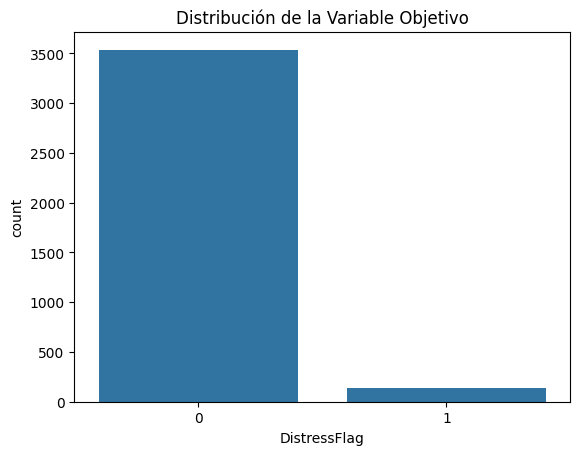

In [7]:
target_counts = df['DistressFlag'].value_counts()
print(target_counts)
print("\nProporción de la variable objetivo:")
print(target_counts / df.shape[0])

sns.countplot(x='DistressFlag', data=df)
plt.title("Distribución de la Variable Objetivo")
plt.show()

DistressFlag
0    286
1    136
Name: count, dtype: int64

Proporción de la variable objetivo (por Empresa):
DistressFlag
0    0.677725
1    0.322275
Name: count, dtype: float64


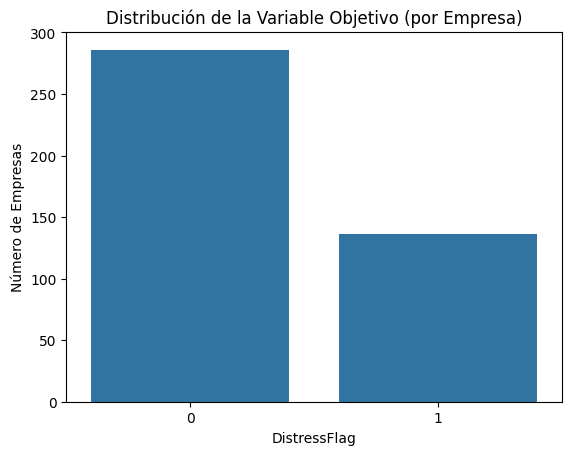

In [8]:
distress_per_company = df.groupby('Company')['DistressFlag'].last()

target_counts = distress_per_company.value_counts()
print(target_counts)
print("\nProporción de la variable objetivo (por Empresa):")
print(target_counts / distress_per_company.shape[0])

sns.countplot(x=distress_per_company)
plt.title("Distribución de la Variable Objetivo (por Empresa)")
plt.xlabel("DistressFlag")
plt.ylabel("Número de Empresas")
plt.show()

In [9]:
total_distress_records = df['DistressFlag'].value_counts()[1]

distress_flag_last_period = df.groupby('Company')['DistressFlag'].last()
companies_distress_last_period = distress_flag_last_period.value_counts()[1]

print("Registros totales en distress del dataset:", total_distress_records)
print("Empresas en distress en su último año:", companies_distress_last_period)

Registros totales en distress del dataset: 136
Empresas en distress en su último año: 136


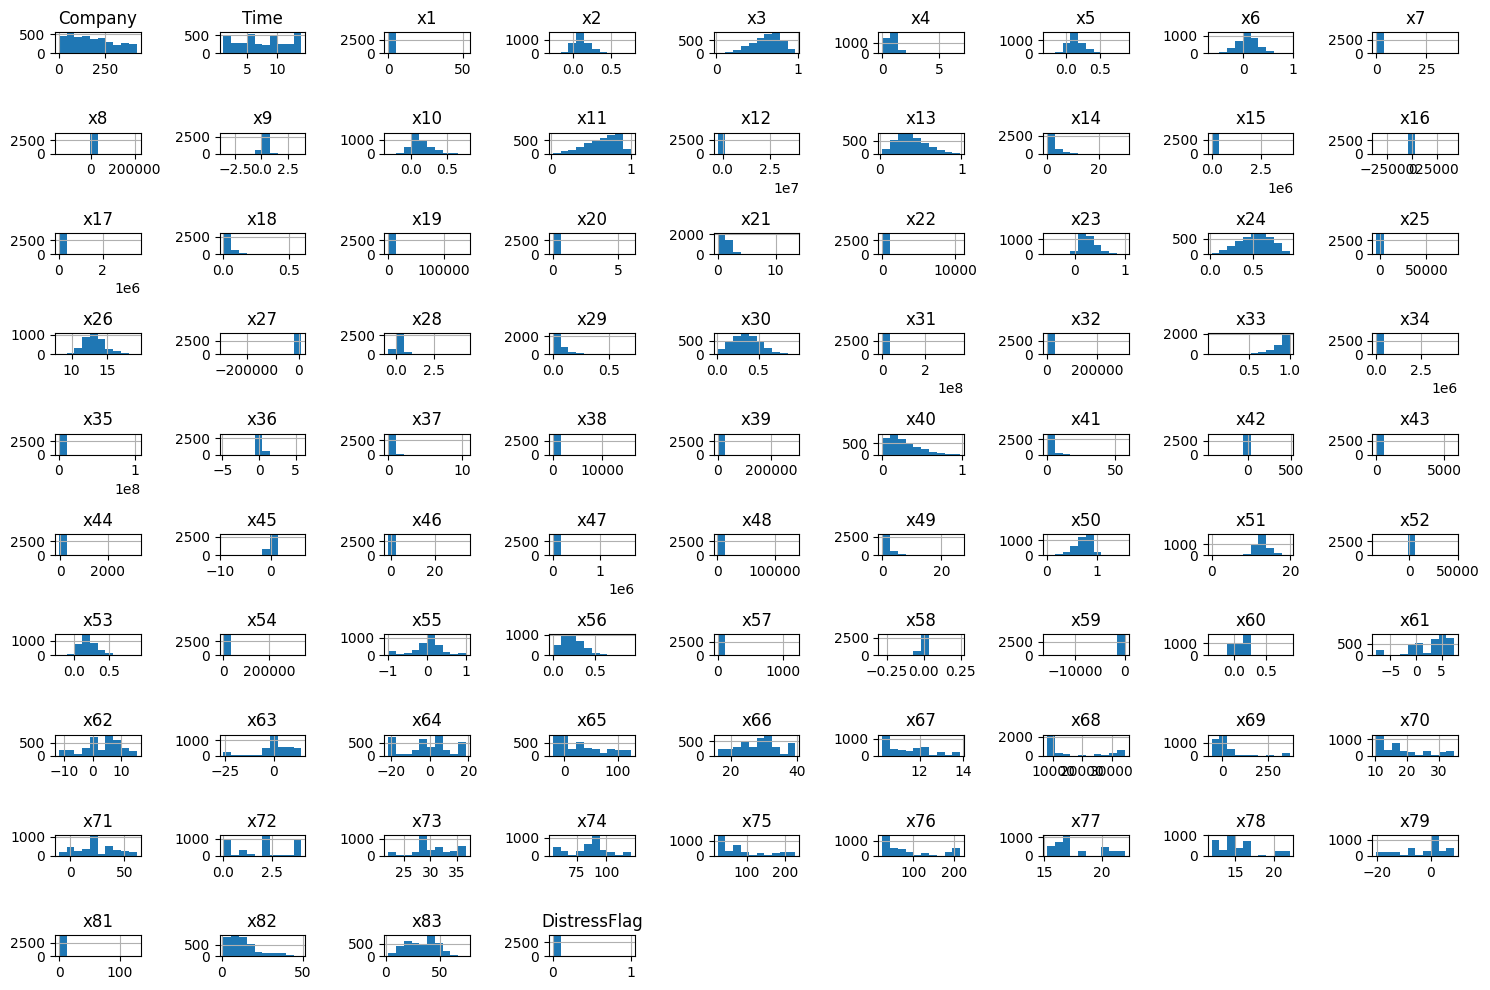

In [10]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

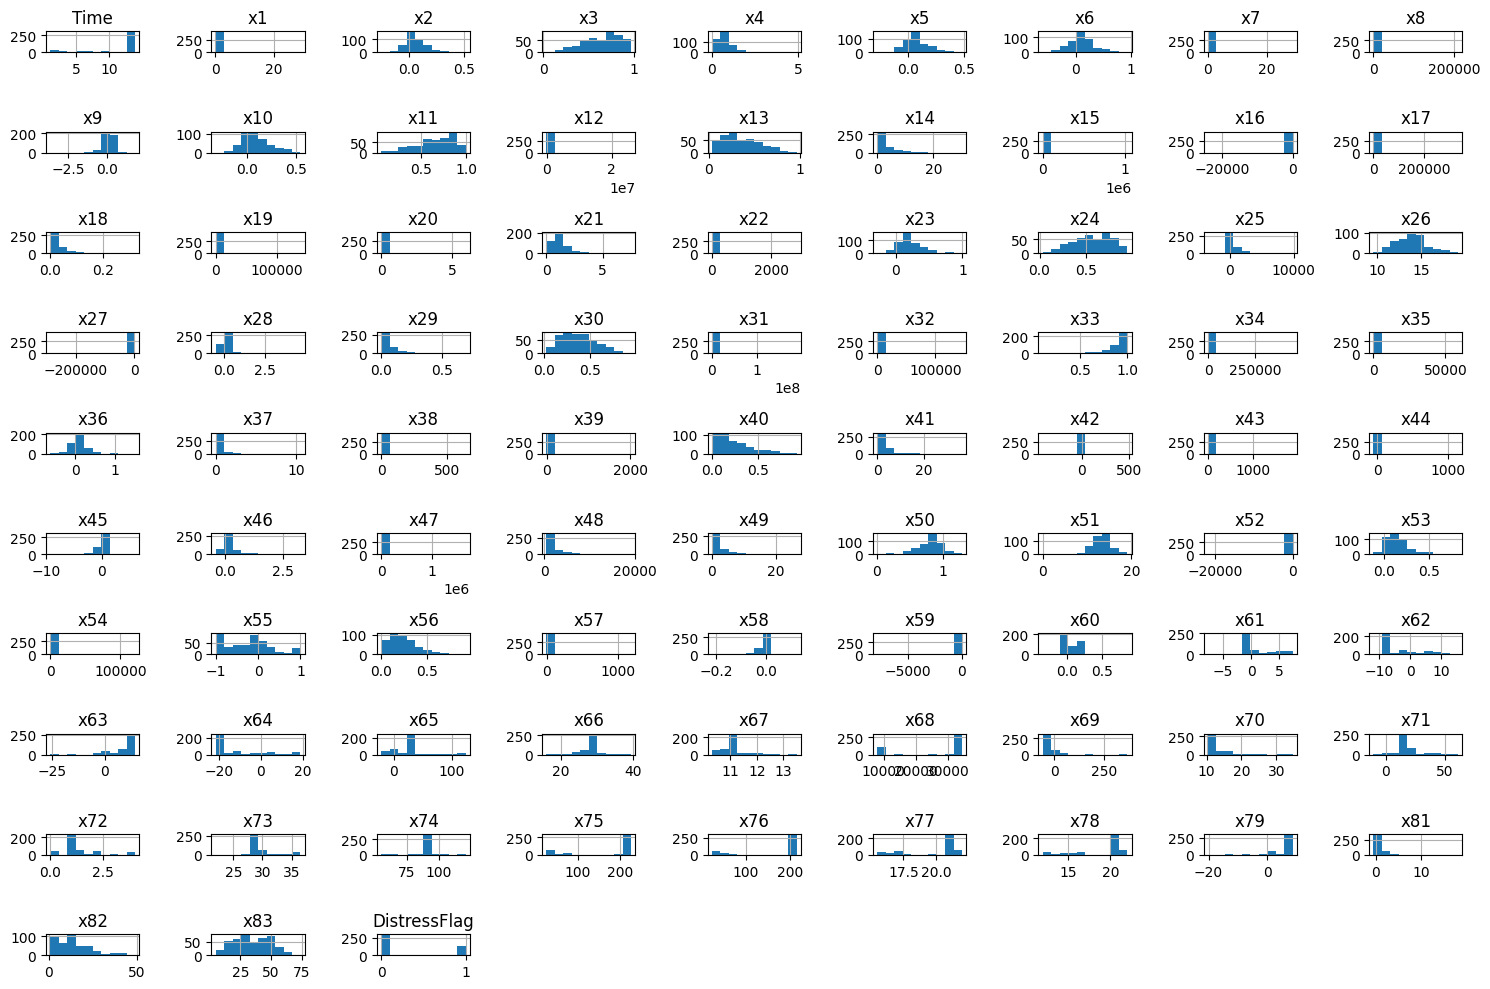

In [11]:
df_last_time_company = df.sort_values('Time')
df_last_time_company = df_last_time_company.groupby('Company').last()
df_last_time_company.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

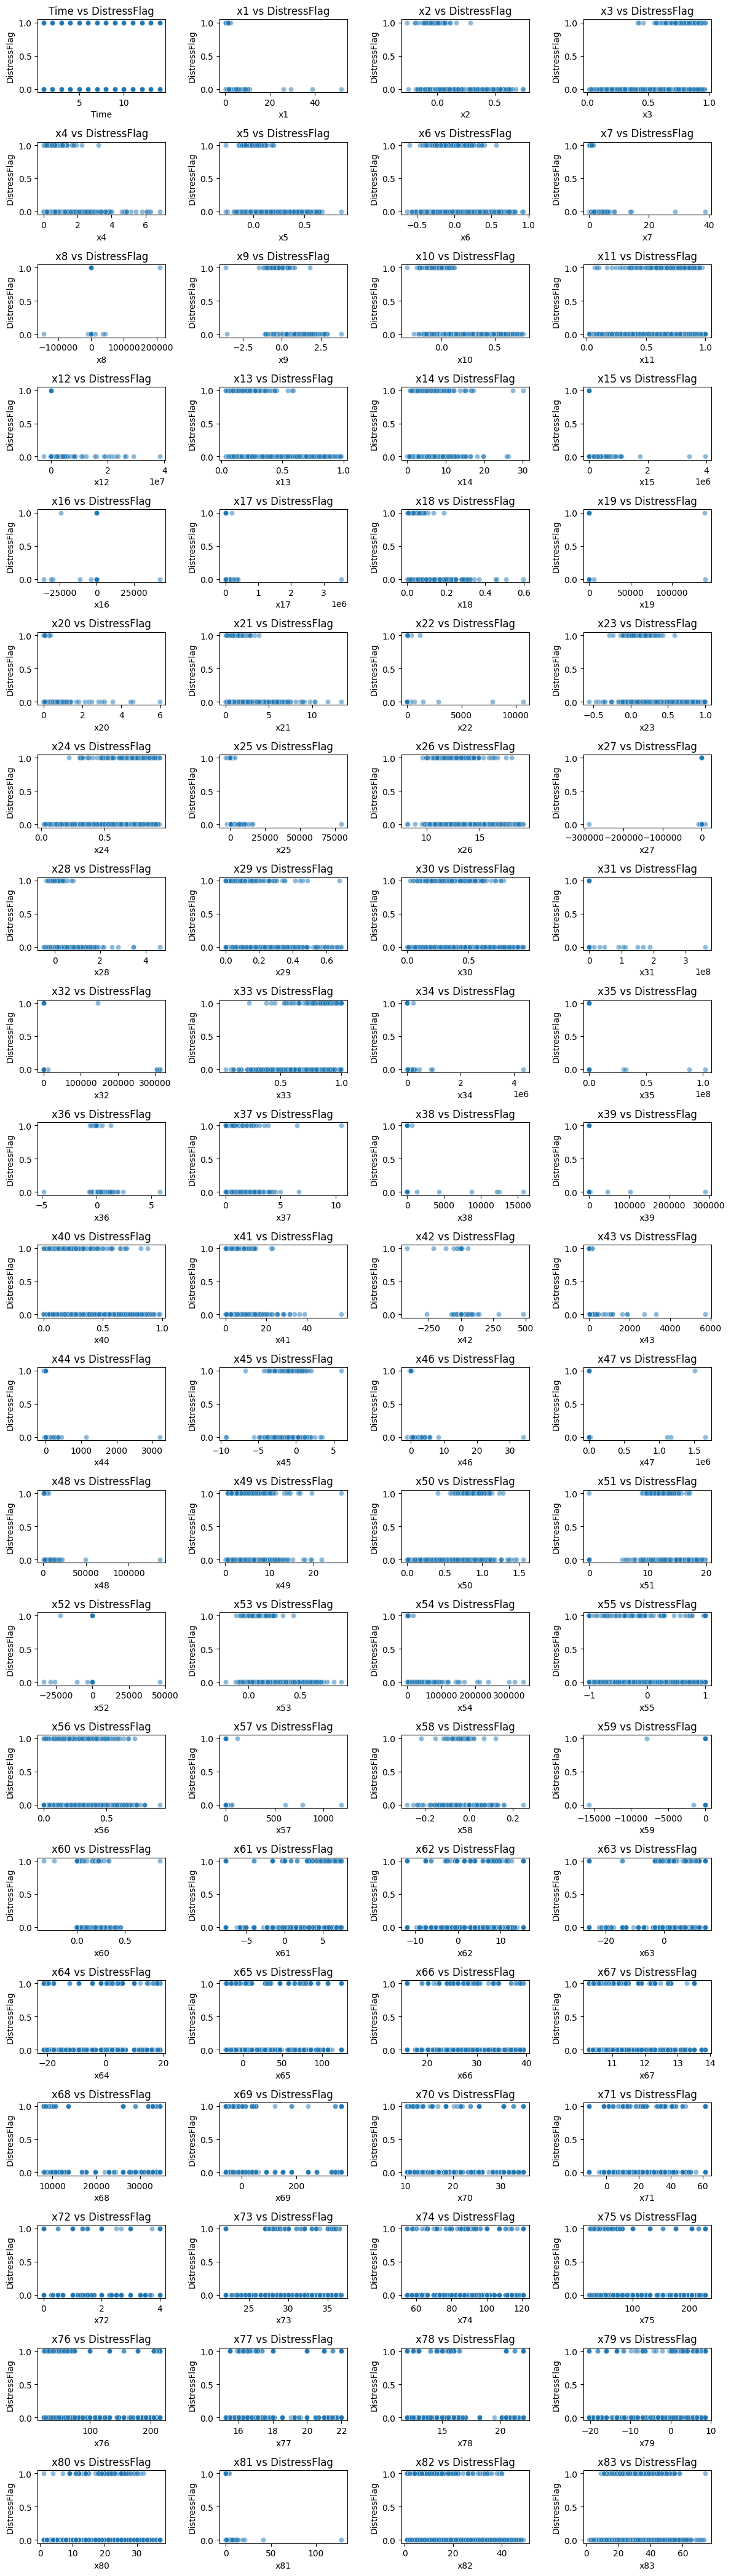

In [12]:
features = [col for col in df.columns if col not in ['Company', 'DistressFlag']]
n_features = len(features)

cols = 4
rows = n_features // cols + (n_features % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2 * rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.scatterplot(x=feature, y='DistressFlag', data=df, alpha=0.5, ax=ax)
    ax.set_title(f'{feature} vs DistressFlag')
    ax.set_xlabel(feature)
    ax.set_ylabel('DistressFlag')

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

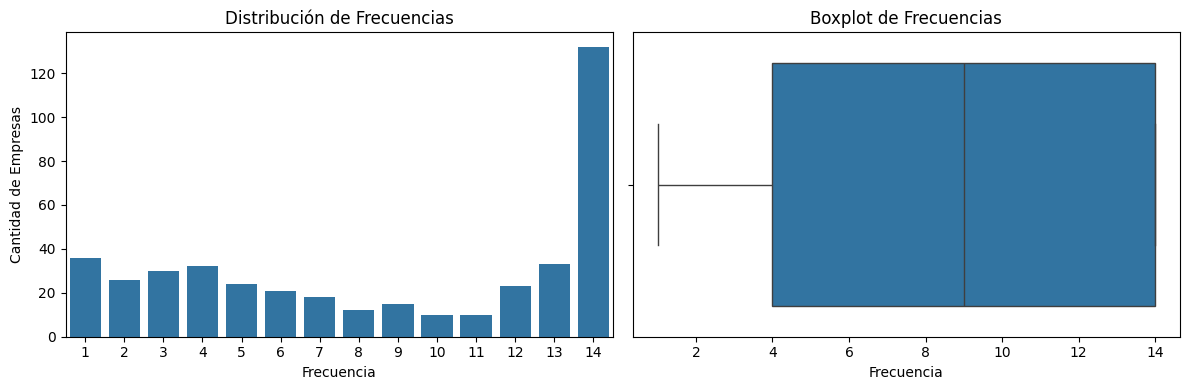

In [13]:
freq = df['Company'].value_counts()

freq_dist = freq.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=freq_dist.index, y=freq_dist.values, ax=axes[0])
axes[0].set_title("Distribución de Frecuencias")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Cantidad de Empresas")

sns.boxplot(x=freq.values, ax=axes[1])
axes[1].set_title("Boxplot de Frecuencias")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

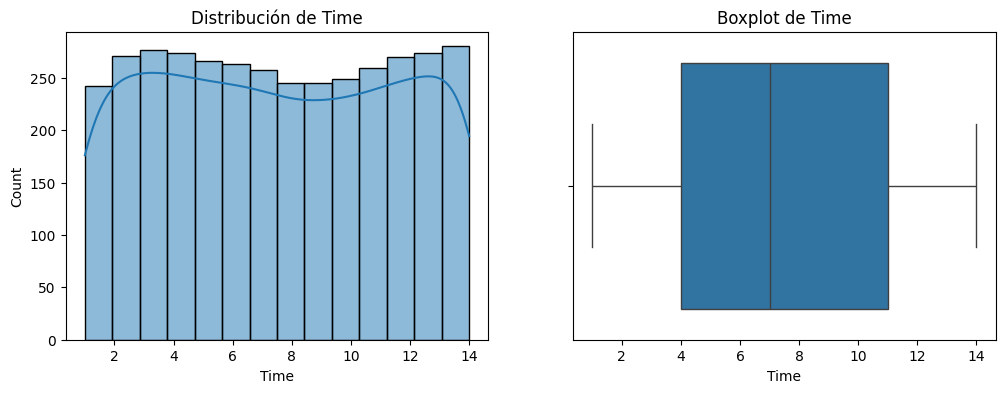

In [14]:
time_max = df['Time'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Time'], ax=axes[0], bins=time_max, kde=True)
axes[0].set_title(f"Distribución de Time")
sns.boxplot(x=df['Time'], ax=axes[1])
axes[1].set_title(f"Boxplot de Time")
plt.show()

## 3. Preprocesado y Extracción de Características

Esta etapa se centra en preparar el dataset para el modelado mediante la generación de distintos subconjuntos de datos:

1. **Dataset completo** — presenta un desbalance importante en la variable objetivo.
2. **Último año por empresa** (`X_last_time`) — usa la instantánea más reciente para cada compañía.
3. **Características extraídas con tsfresh** (`X_extracted`) — captura la dinámica temporal de cada empresa.

> **Nota:** Se reindexa `Company` para que sus valores vayan de `0` a `n‑1` y así evitar desalineaciones de índice durante la validación cruzada.

La integración de estas variantes facilita la evaluación del impacto de cada preprocesado sobre la capacidad predictiva del modelo.

In [15]:
df['Company'] = df['Company'].apply(lambda x: x - 1)

In [16]:
n_jobs = max(1, multiprocessing.cpu_count() - 1)

df = df.sort_values('Time')

X = df.drop(columns=['DistressFlag', 'Company', 'Time'])
y = df['DistressFlag']

X_last_time = df.groupby('Company').last().drop(columns=['DistressFlag', 'Time'])
y_last_time = df.groupby('Company')['DistressFlag'].last()

fc_params = MinimalFCParameters()

X_extracted = extract_features(df.drop(columns=['DistressFlag'] + cat_features), column_id='Company', column_sort='Time', default_fc_parameters=fc_params, n_jobs=n_jobs)
X_extracted = pd.concat([X_extracted, X_last_time.copy()], axis=1)
y_extracted = df.groupby('Company')['DistressFlag'].last()

print("Dimensiones del dataset original:\n", X.shape)
print("Dimensiones del dataset original (último año):\n", X_last_time.shape)
print("Dimensiones del dataset extraído:\n", X_extracted.shape)

Feature Extraction: 100%|██████████| 55/55 [00:03<00:00, 16.33it/s]


Dimensiones del dataset original:
 (3672, 83)
Dimensiones del dataset original (último año):
 (422, 83)
Dimensiones del dataset extraído:
 (422, 903)


## 4. Estrategia de Validación y Evaluación de Modelos

Para evaluar el desempeño de los modelos en un problema desbalanceado se utilizan dos estrategias principales:

- **Validación Cruzada Estratificada (`StratifiedKFold`)** – mantiene la proporción de clases en cada *fold*.
- **Validación Cruzada Estratificada por Grupos (`StratifiedGroupKFold`)** – asegura que las instancias de una empresa no aparecen tanto en entrenamiento como en prueba.

Se evaluarán los siguientes modelos, aplicando escalado cuando sea necesario:

- **Logistic Regression**
- **K-Nearest Neighbors (KNN)**
- **SVM**
- **Random Forest**
- **XGBoost**

La función `evaluate_model` calcula métricas (matriz de confusión, reporte de clasificación, AUC, F1, tiempo de ejecución) y genera la curva ROC para facilitar la comparación entre modelos.

In [17]:
def calculate_metrics(
        y_true: np.ndarray,
        y_pred: np.ndarray,
        y_probs: np.ndarray
    ) -> Dict[str, Any]:
    """
    Calcula las métricas básicas del modelo.

    Parámetros:
    - y_true: Vector de etiquetas verdaderas.
    - y_pred: Vector de etiquetas predichas.
    - y_probs: Vector de probabilidades predichas para la clase positiva.
    
    Devuelve:
    - Diccionario con la matriz de confusión, reporte de clasificación, AUC y F1 Score.
    """
    return {
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'classification_report': classification_report(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_probs),
        'f1_score': f1_score(y_true, y_pred)
    }


def evaluate_model(
        estimator: BaseEstimator,
        X: pd.DataFrame,
        y: np.ndarray,
        cv: int | BaseCrossValidator | Iterable | None = None,
        groups: np.ndarray | None = None,
        threshold: float = 0.5
    ) -> Dict[str, Any]:
    """
    Evalúa un modelo de ML utilizando validación cruzada, calculando métricas y graficando la curva ROC.
    
    Parámetros:
    - estimator: Modelo o Pipeline de ML a evaluar (por ejemplo, SVC, KNeighborsClassifier, etc.).
    - X: DataFrame o matriz de características.
    - y: Vector de etiquetas verdaderas.
    - cv: Estrategia de validación cruzada (por ejemplo, StratifiedKFold).
    - groups: Grupos para la validación cruzada (opcional).
    - threshold: Umbral para convertir probabilidades en predicciones binarias.
    
    Devuelve:
    - Diccionario con las métricas calculadas y el tiempo de ejecución.
    """
    start_time = time.time()
    
    y_probs: np.ndarray = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        groups=groups,
        n_jobs=-1,
        method='predict_proba'
    )[:, 1]

    y_pred: np.ndarray = (y_probs >= threshold).astype(int)
    
    metrics: Dict[str, Any] = calculate_metrics(y, y_pred, y_probs)
    
    execution_time: float = time.time() - start_time
    metrics['execution_time'] = execution_time

    print("Métricas del modelo:")
    print(metrics['confusion_matrix'])
    print(metrics['classification_report'])
    print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Tiempo de ejecución: {execution_time:.2f} segundos")

    RocCurveDisplay.from_predictions(y, y_probs)
    plt.show()

    return metrics

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

groups = df['Company'].values

## 5. Modelado y Evaluación

Para facilitar la comparación, todas las evaluaciones usan **tres subconjuntos de datos**:  

1. **Dataset completo** – todas las observaciones disponibles.  
2. **Último año por empresa** (`X_last_time`) – snapshot más reciente para cada compañía.  
3. **Características extraídas con tsfresh** (`X_extracted`) – estadísticos generados a partir de la serie temporal.

### Pipeline de Preprocesado (`make_preprocessor`)

El mismo flujo se reutiliza para los cinco clasificadores:

1. **`reset_index`**  
   Reinicia el índice del `DataFrame` para que la validación estratificada por grupos no encuentre índices duplicados.
2. **`ColumnTransformer`**  
   - **Variables numéricas**  
     - `SimpleImputer(strategy="median")`  
     - Escalado opcional (`StandardScaler`) cuando el modelo lo requiere.  
   - **Variables categóricas**  
     - `SimpleImputer(strategy="most_frequent")`  
     - `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`  
   El transformador devuelve un `DataFrame` (`set_output(transform="pandas")`) preservando los nombres de las columnas, para poderse visualizar mejor posteriormente en la fase de interpretación del modelo.
3. **`FeatureSelector`** (*tsfresh*)  
   Filtra automáticamente las características más relevantes, reduciendo la dimensionalidad antes de llegar al clasificador.

Cada modelo (Regresión Logística, KNN, SVM, Random Forest, XGBoost) se envuelve en un `Pipeline` con este preprocesado, lo que garantiza que los pasos de imputación, escalado y selección ocurran **dentro** de la validación cruzada, y de ese modo evitar posibles fugas de datos.

In [19]:
def make_preprocessor(scaler: Optional[TransformerMixin] = None) -> Pipeline:
    """
    Crea un Pipeline de preprocesado completo de datos.

    Parámetros:
    - scaler: TransformerMixin opcional para escalar variables numéricas (por ejemplo, StandardScaler).
              Si se pasa None, no se aplica ningún paso de escalado.

    Devuelve:
    - Pipeline de sklearn que engloba:
      * reseteo de índice del DataFrame,
      * column_transform: 
        - imputación y escalado de variables numéricas,
        - imputación y codificación One-Hot de variables categóricas,
      * selección de características mediante FeatureSelector().
    """
    reset = ('reset_index', FunctionTransformer(lambda X: X.reset_index(drop=True)))

    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median'))
    ]
    if scaler is not None:
        numeric_steps.append(('scaler', scaler))
    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ])

    column_transform = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, make_column_selector(dtype_exclude='category')),
            ('cat', categorical_transformer, make_column_selector(dtype_include='category'))
        ],
        remainder='drop',
        verbose_feature_names_out=False
    ).set_output(transform='pandas')

    feature_selection = ('feature_selector', FeatureSelector())

    return Pipeline(steps=[
        reset,
        ('column_transform', column_transform),
        feature_selection
    ])

### Evaluación del Modelo Regresión Logística

Modelo con datos originales:
Métricas del modelo:
[[3502   34]
 [ 109   27]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.44      0.20      0.27       136

    accuracy                           0.96      3672
   macro avg       0.71      0.59      0.63      3672
weighted avg       0.95      0.96      0.95      3672

ROC AUC: 0.9225
F1 Score: 0.2741
Tiempo de ejecución: 5.81 segundos


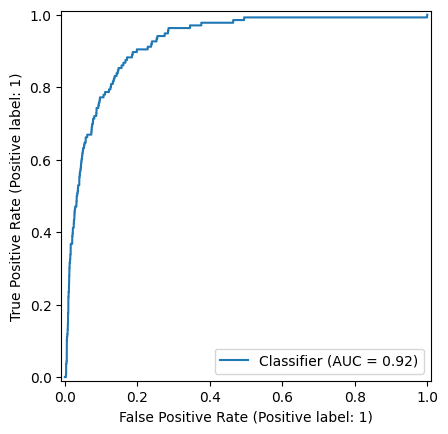

Modelo con datos del último año:
Métricas del modelo:
[[273  13]
 [ 15 121]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       286
           1       0.90      0.89      0.90       136

    accuracy                           0.93       422
   macro avg       0.93      0.92      0.92       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9741
F1 Score: 0.8963
Tiempo de ejecución: 5.97 segundos


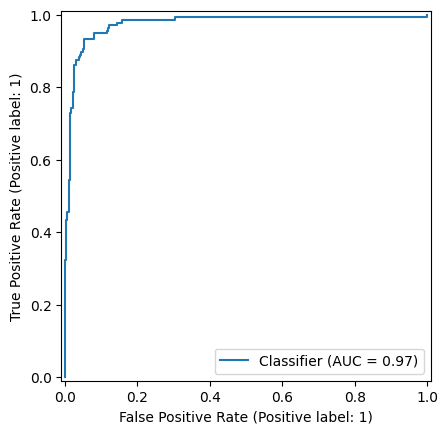

Modelo con datos extraídos:
Métricas del modelo:
[[269  17]
 [ 15 121]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       286
           1       0.88      0.89      0.88       136

    accuracy                           0.92       422
   macro avg       0.91      0.92      0.91       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9653
F1 Score: 0.8832
Tiempo de ejecución: 7.29 segundos


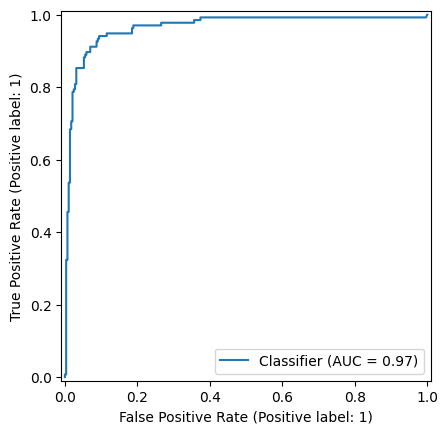

In [20]:
lr_params = {
    'random_state': SEED,
    'max_iter': 1000,
    'solver': 'lbfgs',
    'n_jobs': -1
}

lr_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', LogisticRegression(**lr_params))
])

print("Modelo con datos originales:")
lr_base_eval = evaluate_model(
    lr_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Modelo con datos del último año:")
lr_last_time_eval = evaluate_model(
    lr_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Modelo con datos extraídos:")
lr_extracted_eval = evaluate_model(
    lr_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### Evaluación del Modelo K‑Nearest Neighbors

Modelo con datos originales:
Métricas del modelo:
[[3512   24]
 [ 119   17]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.41      0.12      0.19       136

    accuracy                           0.96      3672
   macro avg       0.69      0.56      0.59      3672
weighted avg       0.95      0.96      0.95      3672

ROC AUC: 0.7811
F1 Score: 0.1921
Tiempo de ejecución: 5.52 segundos


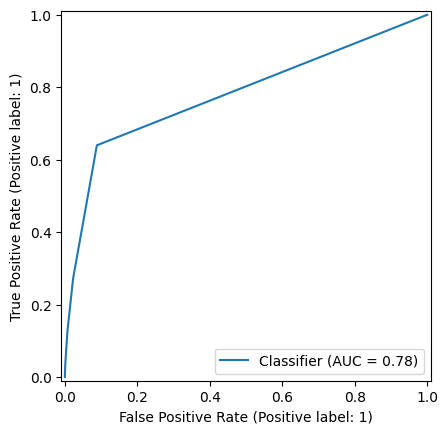

Modelo con datos del último año:
Métricas del modelo:
[[273  13]
 [ 18 118]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       286
           1       0.90      0.87      0.88       136

    accuracy                           0.93       422
   macro avg       0.92      0.91      0.92       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9601
F1 Score: 0.8839
Tiempo de ejecución: 5.31 segundos


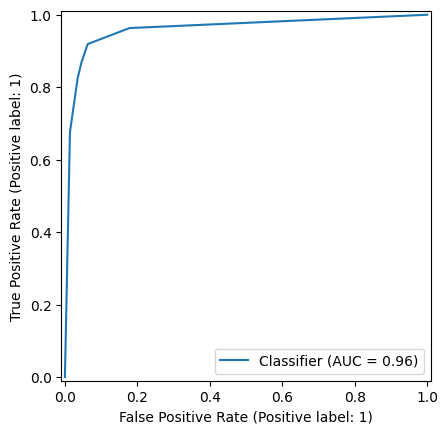

Modelo con datos extraídos:
Métricas del modelo:
[[272  14]
 [ 21 115]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       286
           1       0.89      0.85      0.87       136

    accuracy                           0.92       422
   macro avg       0.91      0.90      0.90       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9537
F1 Score: 0.8679
Tiempo de ejecución: 6.91 segundos


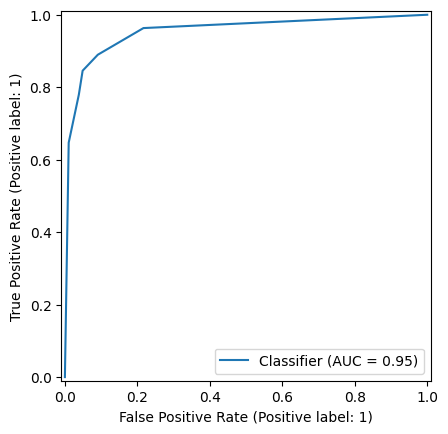

In [21]:
knn_params = {
    'n_neighbors': 5,
    'n_jobs': -1
}

knn_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', KNeighborsClassifier(**knn_params))
])

print("Modelo con datos originales:")
knn_base_eval = evaluate_model(
    knn_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Modelo con datos del último año:")
knn_last_time_eval = evaluate_model(
    knn_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Modelo con datos extraídos:")
knn_extracted_eval = evaluate_model(
    knn_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### Evaluación del Modelo SVM

Modelo con datos originales:
Métricas del modelo:
[[3525   11]
 [ 128    8]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3536
           1       0.42      0.06      0.10       136

    accuracy                           0.96      3672
   macro avg       0.69      0.53      0.54      3672
weighted avg       0.94      0.96      0.95      3672

ROC AUC: 0.7878
F1 Score: 0.1032
Tiempo de ejecución: 5.88 segundos


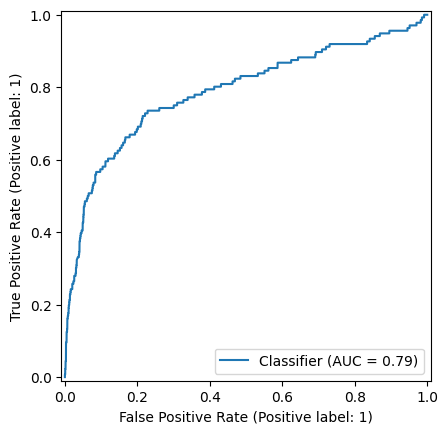

Modelo con datos del último año:
Métricas del modelo:
[[274  12]
 [ 21 115]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       286
           1       0.91      0.85      0.87       136

    accuracy                           0.92       422
   macro avg       0.92      0.90      0.91       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9682
F1 Score: 0.8745
Tiempo de ejecución: 5.00 segundos


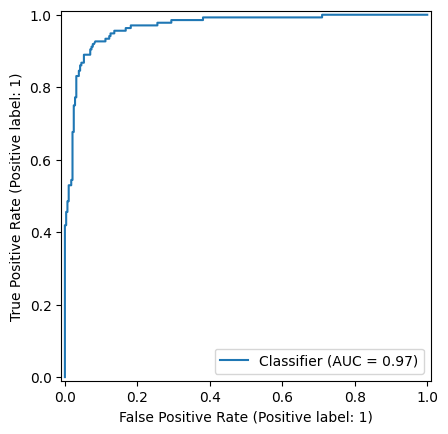

Modelo con datos extraídos:
Métricas del modelo:
[[277   9]
 [ 22 114]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       286
           1       0.93      0.84      0.88       136

    accuracy                           0.93       422
   macro avg       0.93      0.90      0.91       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9657
F1 Score: 0.8803
Tiempo de ejecución: 7.31 segundos


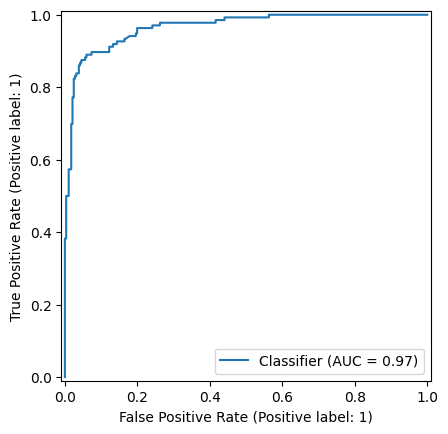

In [22]:
svm_params = {
    'kernel': 'rbf',
    'probability': True,
    'random_state': SEED
}

svm_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', SVC(**svm_params))
])

print("Modelo con datos originales:")
svm_base_eval = evaluate_model(
    svm_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Modelo con datos del último año:")
svm_last_time_eval = evaluate_model(
    svm_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Modelo con datos extraídos:")
svm_extracted_eval = evaluate_model(
    svm_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### Evaluación del Modelo Random Forest

Modelo con datos originales:
Métricas del modelo:
[[3510   26]
 [ 106   30]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.54      0.22      0.31       136

    accuracy                           0.96      3672
   macro avg       0.75      0.61      0.65      3672
weighted avg       0.95      0.96      0.96      3672

ROC AUC: 0.9164
F1 Score: 0.3125
Tiempo de ejecución: 6.52 segundos


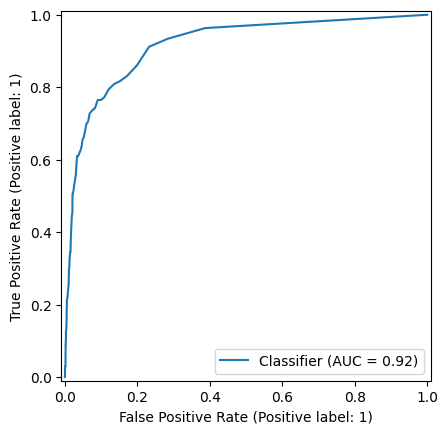

Modelo con datos del último año:
Métricas del modelo:
[[271  15]
 [ 10 126]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       286
           1       0.89      0.93      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.94      0.93       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9758
F1 Score: 0.9097
Tiempo de ejecución: 5.41 segundos


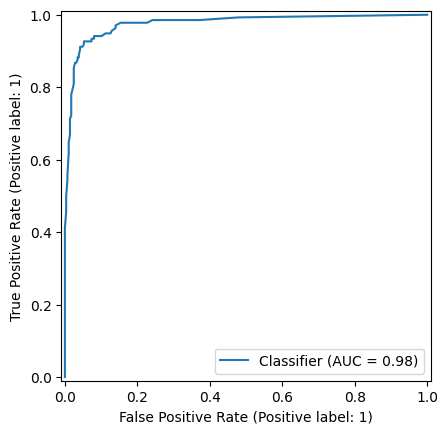

Modelo con datos extraídos:
Métricas del modelo:
[[273  13]
 [ 11 125]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       286
           1       0.91      0.92      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.94      0.94       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9723
F1 Score: 0.9124
Tiempo de ejecución: 7.04 segundos


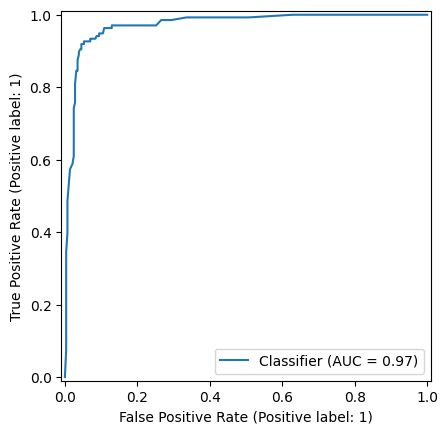

In [23]:
rf_params = {
    'n_estimators': 100,
    'random_state': SEED,
    'n_jobs': -1
}

rf_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestClassifier(**rf_params))
])

print("Modelo con datos originales:")
rf_base_eval = evaluate_model(
    rf_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Modelo con datos del último año:")
rf_last_time_eval = evaluate_model(
    rf_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Modelo con datos extraídos:")
rf_extracted_eval = evaluate_model(
    rf_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### Evaluación del Modelo XGBoost

Modelo con datos originales:
Métricas del modelo:
[[3503   33]
 [ 102   34]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.51      0.25      0.33       136

    accuracy                           0.96      3672
   macro avg       0.74      0.62      0.66      3672
weighted avg       0.95      0.96      0.96      3672

ROC AUC: 0.9236
F1 Score: 0.3350
Tiempo de ejecución: 5.81 segundos


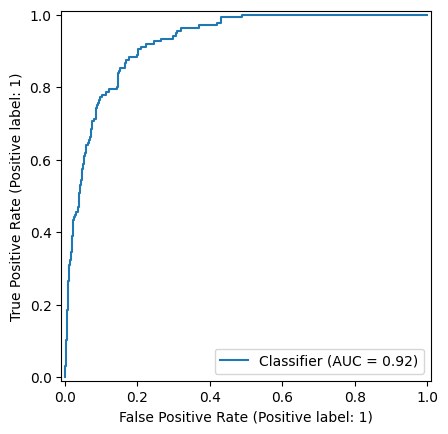

Modelo con datos del último año:
Métricas del modelo:
[[272  14]
 [ 12 124]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       286
           1       0.90      0.91      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.93      0.93       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9791
F1 Score: 0.9051
Tiempo de ejecución: 5.35 segundos


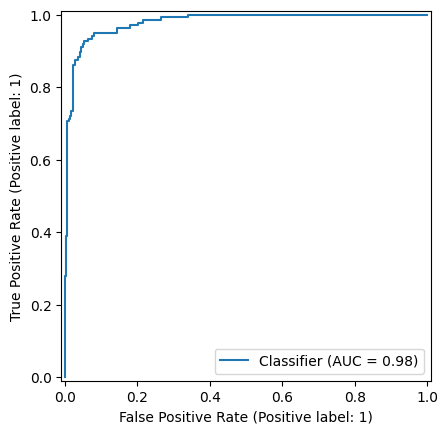

Modelo con datos extraídos:
Métricas del modelo:
[[273  13]
 [ 12 124]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       286
           1       0.91      0.91      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.93      0.93       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9779
F1 Score: 0.9084
Tiempo de ejecución: 7.96 segundos


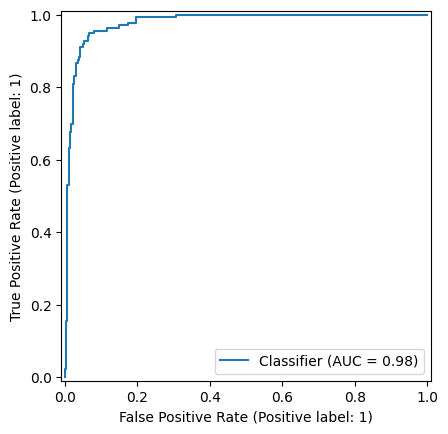

In [24]:
xgb_params = {
    'eval_metric': 'logloss',
    'random_state': SEED,
    'n_jobs': -1
}

xgb_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', XGBClassifier(**xgb_params))
])

print("Modelo con datos originales:")
xgb_base_eval = evaluate_model(
    xgb_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Modelo con datos del último año:")
xgb_last_time_eval = evaluate_model(
    xgb_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Modelo con datos extraídos:")
xgb_extracted_eval = evaluate_model(
    xgb_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

## 6. Interpretabilidad del Modelo con SHAP

Se escoge el modelo que más nos convenza (XGBoost), se entrena sobre el conjunto completo y se interpretan sus resultados con SHAP.

El *summary plot* en barras muestra la **importancia global** de cada característica, mientras que el gráfico *beeswarm* refleja la **dirección y magnitud** del efecto para cada instancia.

In [25]:
xgb_pipeline.fit(X_extracted, y_extracted)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('reset_index',
                                  FunctionTransformer(func=<function make_preprocessor.<locals>.<lambda> at 0x7f08cc9c29e0>)),
                                 ('column_transform',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median'))]),
                                                                   <sklearn.compose._column_transformer.make_column_selector object at 0x7f08cc6d0...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

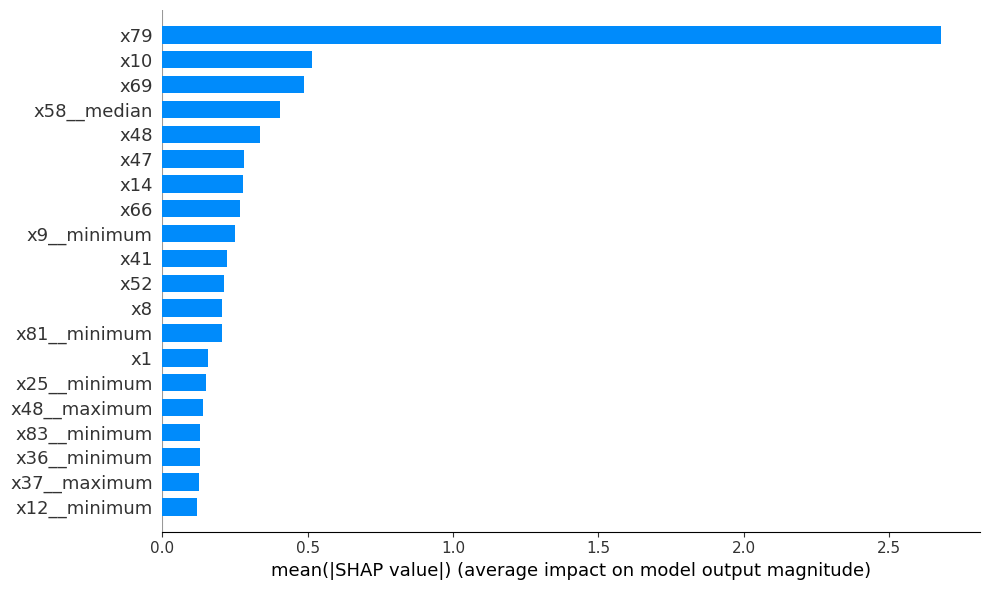

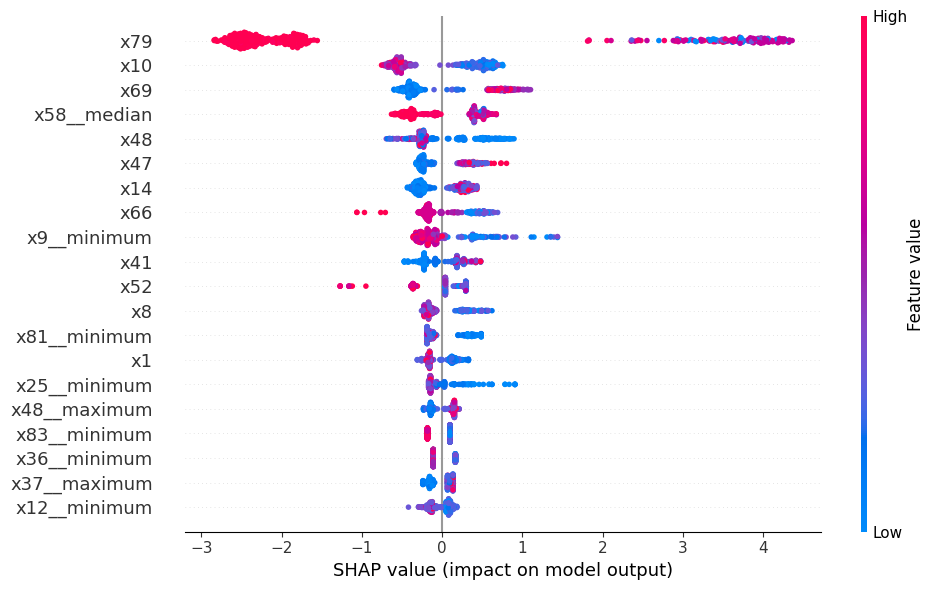

In [26]:
model = xgb_pipeline.named_steps['model']
preprocessor = xgb_pipeline.named_steps['preprocessor']
X_transformed = preprocessor.transform(X_extracted)

explainer = shap.Explainer(model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed, plot_type='bar', plot_size=(10, 6), rng=SEED)
shap.summary_plot(shap_values, X_transformed, plot_size=(10, 6), rng=SEED)

## 7. Conclusiones y Próximos Pasos

### Conclusiones
- **Resumen del proceso:** definición del caso de uso, exploración del conjunto de datos, extracción de características con *tsfresh*, evaluación de modelos en los distintos dataframes e interpretación del modelo final con SHAP.
- **Modelo seleccionado:** XGBoost entrenado sobre `X_extracted` — ROC‑AUC: 0.9779 · F1: 0.9084. Se eligió por su sólido desempeño y por aprovechar la información temporal.
- **Hallazgos principales:**
  - Impacto marginal de la extracción temporal.
  - Dominio de los modelos basados en árboles.
  - Las variables `x79`, `x10` y `x69` obtuvieron los valores medios absolutos de SHAP más altos en el modelo XGBoost.

### Próximos Pasos
1. Optimizar hiperparámetros con GridSearchCV.
2. Explorar ensamblajes para mayor robustez.
3. Ampliar el dataset con variables macroeconómicas.

### Reflexión
Aunque las métricas no mejoraron con las características temporales, se mantiene la preferencia por un modelo que las incorpore, ya que aporta mayor robustez.

### Celda opcional – guardado del modelo final

Si se desea, se puede descomentar la celda siguiente para guardar el modelo final (XGBoost) y cargarlo posteriormente con:

```python
import joblib
model = joblib.load('modelo_xgb_final.pkl')
```

In [27]:
# Opcional: Guardar el modelo final (descomentar para ejecutar)
# import joblib
# joblib.dump(xgb_pipeline.named_steps['model'], 'modelo_xgb_final.pkl')
# print("Modelo guardado exitosamente.")